(ch-ml-landscape)=
# 머신러닝 소개

:::{note} 감사의 글

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.
:::

컴퓨터에 위키백과 문서를 단순히 저장한다고 해서 컴퓨터가 똑똑해지는 것은 아니다.
반면 머신러닝을 이용해 그 문서들을 학습시키면, 스스로 패턴을 파악하여 주어진 문제를 해결하는 능력을 갖추게 된다.

## 머신러닝 모델

### 전통적 프로그래밍

전통적인 프로그래밍은 일정한 과정을 따라 진행된다.
먼저 문제 연구 단계에서 해결해야 할 문제를 분석하고, 이를 해결할 수 있는 알고리즘을 연구한다. 
다음으로 규칙 작성 단계에서는 연구된 알고리즘을 실제 코드로 구현한다. 
이후에는 평가 단계가 이어지는데, 이 단계에서는 구현된 프로그램을 테스트하여 올바르게 작동하는지 확인한다.
테스트를 통과하면 프로그램은 실전 배치된다.
그러나 테스트에 실패할 경우, 발생한 오차를 분석한 뒤 다시 문제 연구 단계로 돌아가 알고리즘을 수정하고 개선하는 과정을 반복한다.

<div align="center">
  <img src="https://github.com/codingalzi/handson-ml3/blob/master/jupyter-book/imgs/ch01/homl01-01.png?raw=true" width="400">
</div>

예를 들어, 전통적인 프로그래밍 방식으로 구현된 스팸 메일 분류기는 특정 단어가 이메일 제목에 포함되면 스팸으로 처리하도록 규칙을 작성한다. 개발자는 직접 코드에 조건문을 넣어 “제목에 ‘무료’, ‘당첨’, ‘신용카드 정보’, ‘광고’ 등이 있으면 스팸으로 분류하라”는 규칙을 명시한다.  

```python
if "무료" in subject or "당첨" in subject or "신용카드 정보" in subject:
    label = "spam"
else:
    label = "ham"
```

이처럼 규칙을 코드로 작성해두면 초기에는 잘 작동한다. 하지만 프로그램이 실제로 운영된 이후 새로운 스팸 단어가 등장하면 기존 규칙만으로는 제대로 분류하지 못한다. 따라서 개발자가 매번 새로운 규칙을 추가하거나 수정해야 하며, 이로 인해 유지 보수가 매우 어렵다.

### 머신러닝 프로그래밍

스팸으로 지정된 메일에 '무료', '당첨', '신용카드 정보', '광고', '투^^자', '무&#10084;료' 등의 표현이 
자주 등장하는 경우 새로운 메일에 그런 표현이 사용되면 
자동으로 스팸으로 분류하도록 **스스로 학습하는 프로그램인 머신러닝 모델**을 작성한다.

<div align="center">
    <img src="https://github.com/codingalzi/handson-ml3/blob/master/jupyter-book/imgs/ch01/homl01-02.png?raw=true" width="420">
</div>

스팸 메일 분류 머신러닝 모델의 학습은 스팸 메일과 아닌 메일의 구분법을 학습하기 위해
다량의 스팸 메일과 스팸이 아닌 메일로 구성된 훈련셋을 활용한다.
학습이 완료된 스팸 메일 분류 머신러닝 모델은 새로운 이메일에 대해
학습된 정보를 이용하여 스팸인지 아닌지 판별한다.

**머신러닝 모델 훈련 자동화**

머신러닝 모델이 주어진 데이터로부터 필요한 정보를 학습하도록 하는 과정이 **모델 훈련**이다.
모델 훈련은 **머신러닝 파이프라인** 
또는 **MLOps(Machine Learning Operations, 머신러닝 운영)** 기법 등을 활용하여
자동화할 수 있다.
예를 들어, MLOps는 기존에 학습되지 않은 새로운 종류의 스팸 메일이 많이 신고되는 경우
신고된 스팸 메일의 내용을 분석한 다음에
스팸 메일 분류 모델을 새로운 훈련셋에 대한 훈련을 자동화하는 데에 활용될 수 있다.

<div align="center">
    <img src="https://github.com/codingalzi/handson-ml3/blob/master/jupyter-book/imgs/ch01/homl01-03.png?raw=true" width="440">
</div>

**머신러닝 프로그래밍의 장점**

머신러닝 프로그래밍은 전통적인 규칙 기반 접근 방식으로는 유지보수가 어렵거나 해결하기 힘든 문제들을 보다 효율적으로 다룰 수 있게 한다. 예를 들어, 스팸 메일 분류기는 수많은 규칙을 직접 작성해야 하는데, 머신러닝을 활용하면 이러한 복잡한 규칙을 자동으로 학습하여 훨씬 간단하게 구현할 수 있다.

또한 음성 인식처럼 전통적인 방식으로는 지나치게 복잡한 문제도 머신러닝을 통해 해결할 수 있다. 머신러닝 모델은 새로운 환경과 데이터에 쉽게 적응할 수 있어 변화하는 상황에서도 유연하게 대응할 수 있는 시스템을 개발할 수 있다.

마지막으로, 머신러닝은 복잡한 문제와 방대한 데이터를 분석하여 기존 방식으로는 얻기 어려운 깊은 통찰을 제공한다. 이는 빅데이터 시대에 특히 중요한 장점으로, 데이터 속에 숨겨진 패턴과 의미를 발견하는 데 큰 도움을 준다.

<div align="center">
    <img src="https://github.com/codingalzi/handson-ml3/blob/master/jupyter-book/imgs/ch01/homl01-04.png?raw=true" width="440">
</div>

### 머신러닝 활용 사례

아래 그림은 다양한 분야에서 활용되고 있는 머신러닝 기술의 대표적인 활용 사례들을 시각적으로 정리한 인포그래픽입니다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-ml/blob/master/images/ch01/applications-of-ML.jpg?raw=true" width="600">
</div>

### 머신러닝 모델 유형

아래 표는 머신러닝 모델을 학습 유형과 과제에 따라 구분한다.

| 학습 유형        | 과제        |
|----------------------|-----------------|
| 지도 학습            | 회귀            |
| 자기 지도 학습       | 분류            |
| 준지도 학습          | 군집화          |
| 비지도 학습          | 차원 축소       |
| 강화 학습            | 이상치 탐지 |
|                  | 신규 데이터 탐지 |

이 강의노트에서는 지도 학습으로 회귀와 분류 모델을 훈련시키는 모델을 살펴본다.

## 선형 회귀 모델 훈련

### 삶의 만족도 데이터셋

OECD(경제협력개발기구) 국가의 구매력 기준 **1인당 GDP**<font size='2'>GDP per capita</font>와 
해당 국가 국민의 **삶의 만족도**<font size='2'>Life Satisfaction</font> 사이의 
관계를 머신러닝 모델을 활용하여 확인한다.

GDP는 **국내 총생산**<font size='2'>Gross Domestic Product</font>의 줄임말이며, 한 나라의 국경 안에서 일정한 기간 동안 생산된 모든 최종 생산물(재화와 서비스)의 시장 가치의 총합을 의미한다. 
1인당 GDP(GDP per capita)는 특정 국가의 국내 총생산(GDP)을 총인구수로 나눈 값이며, 한 나라의 국민 평균 생활 수준이나 전반적인 경제적 부를 비교할 때 활용되는 대표적인 지표로 사용된다.

머신러닝 모델 훈련을 위해 2020년 기준으로 OECD 회원국 40개 국가와
비회원국 3개 국가 등 총 40개 국가를 대상으로 조사된 국가별 1인당 GDP와 삶의 만족도 데이터를 활용한다.

| 지역         | OECD 회원국                              | 기타                  |
|--------------|----------------------------------------|--------------------------|
| 유럽         | 오스트리아, 벨기에, 체코, 덴마크, 에스토니아, 핀란드,<br> 프랑스, 독일, 그리스, 헝가리, 아이슬란드, 아일랜드, <br>이탈리아, 라트비아, 리투아니아, 룩셈부르크, 네덜란드, <br> 노르웨이, 폴란드, 포르투갈, 슬로바키아, 슬로베니아,<br> 스페인, 스웨덴, 스위스, 튀르키예, 영국 | 브라질 |
| 북미         | 캐나다, 미국, 멕시코                                                   | 러시아 |
| 아시아-태평양 | 일본, 한국, 호주, 뉴질랜드                                              | 남아프리카공화국 |
| 중남미       | 칠레, 콜롬비아                                           |  |
| 중동         | 이스라엘                                                               |   |

**필수 라이브러리 불러오기**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**삶의 만족도 데이터셋 다운로드**

In [14]:
data_root = "https://github.com/codingalzi/code-workout-ml/raw/master/notebooks/datasets/"

lifesat_full = pd.read_csv(data_root + "lifesat/lifesat_full.csv")
lifesat_full.head()

,Country,GDP per capita (USD),Life satisfaction
0,South Africa,11466.189672,4.7
1,Colombia,13441.492952,6.3
2,Brazil,14063.982505,6.4
3,Mexico,17887.750736,6.5
4,Chile,23324.524751,6.5


국가명을 행 인덱스로 지정한다.

In [15]:
lifesat_full = lifesat_full.set_index("Country")
lifesat_full

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Chile,23324.524751,6.5
Russia,26456.387938,5.8
Greece,27287.083401,5.4
Turkey,28384.987785,5.5
Latvia,29932.493910,5.9


2020년도 기준 37개 OECD 회원국과 함께 3개 국가가 추가된 총 40개 국가의 데이터로 구성된 데이터프레임이 생성되었다.
포함된 두 개의 특성(변수) 모두 부동소수점 자료형이며 결측치는 없다.

In [16]:
lifesat_full.info()

<class 'pandas.DataFrame'>
Index: 40 entries, South Africa to Luxembourg
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP per capita (USD)  40 non-null     float64
 1   Life satisfaction     40 non-null     float64
dtypes: float64(2)
memory usage: 1.2 KB


1인당 GDP와 삶의 만족도 두 특성 변수의 기초 통계량은 다음과 같다.

In [17]:
lifesat_full.describe()

,GDP per capita (USD),Life satisfaction
count,40.000000,40.000000
mean,42191.165573,6.535000
std,19027.896572,0.752279
min,11466.189672,4.700000
25%,30838.337027,5.900000
50%,40309.638825,6.500000
75%,50743.082138,7.225000
max,110261.157353,7.600000


### 훈련셋 지정

**훈련 목적**

머신러닝 모델을 훈련시키려면 먼저 훈련의 목적을 명확히 해야 한다.
여기서는 다음 두 가지 목표를 달성하고자 한다.

첫째, 국가의 1인당 GDP가 증가할수록 해당 국가 국민의 삶의 만족도가 선형적으로 높아진다는 가정 하에 1인당 GDP가 알려진 국가의 삶의 만족도를 예측하는 **선형 회귀 모델**<font size="2">linear regression model</font>을 훈련시킨다.

둘째, 머신러닝 모델을 훈련시킬 때 발생할 수 있는 과대적합 문제를 설명하기 위해
고의로 8개 국가의 데이터를 데이터셋에서 제외시키고 훈련 시킬 때와 그렇지 않을 때를 비교한다.

**제외 대상 국가 지정**

1인당 GDP가 하위 10% 또는 상위 10% 구간에 포함되는 국가들을 제외 대상으로 지정된다.

In [18]:
gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

min_gdp = lifesat_full[gdppc_col].quantile(0.1)
max_gdp = lifesat_full[gdppc_col].quantile(0.9)

gdp_mask = (lifesat_full[gdppc_col] >= min_gdp) & (lifesat_full[gdppc_col] <= max_gdp)
lifesat = lifesat_full[gdp_mask]
lifesat.info()

<class 'pandas.DataFrame'>
Index: 32 entries, Chile to United States
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP per capita (USD)  32 non-null     float64
 1   Life satisfaction     32 non-null     float64
dtypes: float64(2)
memory usage: 1011.0 bytes


40개 국가 중에서 다음 8개 국가가 제외되었다.

In [34]:
excluded_countries = lifesat_full[~ gdp_mask]
excluded_countries

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Norway,63585.903514,7.6
Switzerland,68393.306004,7.5
Ireland,89688.956958,7.0
Luxembourg,110261.157353,6.9


### 데이터 탐색

아래 코드는 1인당 GDP 기준 하위 10%에서 상위 10% 사이의 국가들을 대상으로
1인당 GDP와 삶의 만족도의 관계를 산점도로 보여준다.
국가의 1인당 GDP가 증가할 수록 삶의 만족도가 선형적<font size="2">linear</font>으로 증가하는 경향이 보인다.

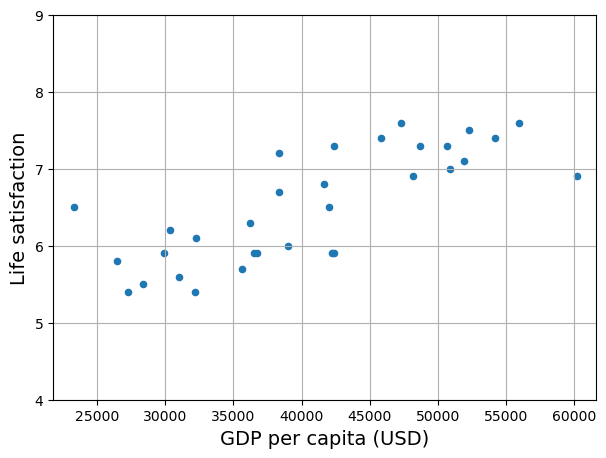

In [20]:
lifesat.plot(kind='scatter', figsize=(7, 5), grid=True, x=gdppc_col, y=lifesat_col)

# 축별로 축 limits 설정
min_life_sat = 4
max_life_sat = 9
plt.axis([min_gdp-1000, max_gdp+1000, min_life_sat, max_life_sat])

plt.show()

두 특성 변수의 피어슨 상관계수가 0.77 정도로 매우 높은 편이다.

In [21]:
lifesat.corr()

,GDP per capita (USD),Life satisfaction
GDP per capita (USD),1.000000,0.771295
Life satisfaction,0.771295,1.000000


### 선형 회귀 모델

국가의 1인당 GDP와 삶의 만족도 사이의 선형 상관관계를 학습하는 모델은 **선형 회귀 모델**<font size="2">linear regression model</font>이다.

여기서 말하는 선형 회귀 모델은 특정 국가의 1인당 GDP가 주어졌을 때 다음과 같은 일차 방정식을 이용하여 해당 국가의 삶의 만족도를 예측(계산)하는 알고리즘(프로그램)을 의미한다.

$$
\text{삶의 만족도} = \theta_0 + (\text{1인당 GDP}) \cdot \theta_1
$$

**선형 회귀 모델의 성능 평가**

선형 회귀 모델의 성능은 1차 방정식에 사용된 절편 $\theta_0$와 기울기 $\theta_1$에 의해 결정된다.

예를 들어, 아래 그래프는
1인당 GDP와 삶의 만족도 사이의 선형 관계를 
적절하지 않게 모델링하는 세 가지 선형 회귀 모델을 보여준다.

- 빨강선 모델: 전혀 학습되지 않은 모델이다.
- 초록선 모델: 양의 선형 상관관계를 음의 선형 상관관계로 완전히 잘못 학습한 모델이다.
- 파랑선 모델: 1인당 GDP와 삶의 만족도 사이의 변화 경향을 나름 잘 반영하지만,
    y-축 절편 $\theta_0$가 조금 작아서 예측값이 전반적으로 낮게 계산된다.


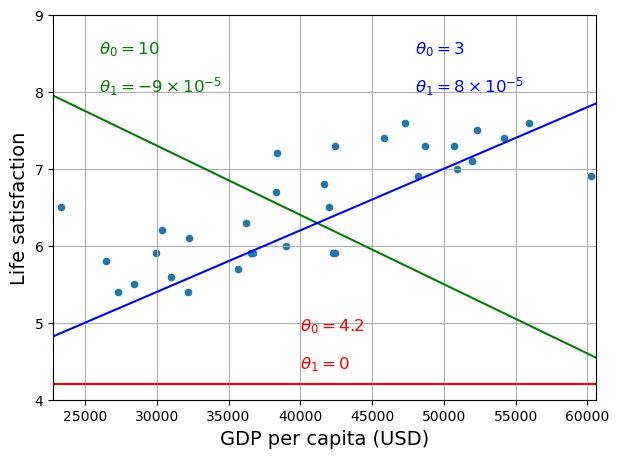

In [22]:
lifesat.plot(kind='scatter', figsize=(7, 5), grid=True, x=gdppc_col, y=lifesat_col)

X_range = np.linspace(min_gdp, max_gdp, 1000)

w1, w2 = 4.2, 0
plt.plot(X_range, w1 + w2 * 1e-5 * X_range, "r")
plt.text(40_000, 4.9, fr"$\theta_0 = {w1}$", color="r")
plt.text(40_000, 4.4, fr"$\theta_1 = {w2}$", color="r")

w1, w2 = 10, -9
plt.plot(X_range, w1 + w2 * 1e-5 * X_range, "g")
plt.text(26_000, 8.5, fr"$\theta_0 = {w1}$", color="g")
plt.text(26_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="g")

w1, w2 = 3, 8
plt.plot(X_range, w1 + w2 * 1e-5 * X_range, "b")
plt.text(48_000, 8.5, fr"$\theta_0 = {w1}$", color="b")
plt.text(48_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

plt.show()

### 회귀 모델 훈련

선형 회귀 모델이 정확한 예측값을 계산하려면 두 개의 파라미터인 절편 $\theta_0$와 기울기 $\theta_1$이 적절해야 한다.
이전 그래프에서 빨강선 모델과 초록선 모델은 두 파라미터 모두 부적절했다.
반면에 파랑선 모델은 기울기 파라미터는 적절해 보였지만 절편 파라미터가 부적절했다.

머신러닝 모델의 훈련은 $\theta_0$와 $\theta_1$처럼 적절한 예측값 계산에 필요한 
최적의 파라미터들을 데이터셋 학습을 통해 찾아가는 과정이을 가리킨다.

**지도 학습**

머신러닝 모델을 지도 학습 방식으로 훈련시키려면 훈련셋을 입력 데이터셋과 타깃셋으로 구분해야 한다.
입력 데이터는 모델이 학습해야 하는 대상이고, 반면에 타깃은 모델이 예측해야 하는 값이다.
이처럼 예측해야 하는 값이 정해진 모델을 학습시키는 방법이
**지도 학습**<font size='2'>supervised learning</font>이다.

**scikit-learn 모델의 입력 데이터셋과 타깃셋**

scikit-learn(사이킷런)은 머신러닝 전용 파이썬 라이브러리이며,
머신러닝 훈련에 필요한 다양한 모델과 도구를 제공한다.
사이킷런 모델 훈련을 위한 입력 데이터셋과 타깃셋은
모두 데이터프레임 또는 넘파이 2차원 어레이로 지정되어야 한다.
여기서는 데이터프레임을 사용한다.

1인당 GDP가 주어졌을 때 해당 국가의 삶의 만족도를 예측하는 선형 회귀 모델을 훈련시켜야 하기에
입력 데이터셋과 타깃셋은 다음과 지정된다.

**입력 데이터셋**

32개 국가의 1인당 GDP를 포함하는 데이터프레임으로 지정한다.

In [25]:
X = lifesat[["GDP per capita (USD)"]]

**타깃셋**

32개 국가의 삶의 만족도를 포함하는 데이터프레임으로 지정한다.

In [26]:
y = lifesat[["Life satisfaction"]]

:::{note} 입력 데이터셋 vs 훈련셋

입력 데이터셋을 훈련셋으로 부르기도 하며, 여기서도 혼용해서 사용한다.
:::

**선형 회귀 모델 지정**

사이킷런의 선형 회귀 모델은 사이킷런 라이브러의 `linear_model` 모듈에 포함된 `LinearRegression` 클래스의 인스턴스로 지정한다.

- `sklearn.linear_model`: 사이킷런 라이브러리의 선형 회귀 모델 관련 모듈
- `LinearRegression`: 선형 회귀 모델의 클래스

In [27]:
from sklearn.linear_model import LinearRegression

oecd_linear_model = LinearRegression()

`oecd_linear_model`는 아직 훈련이 되지 않은 선형 회귀 모델을 가리키며,
앞서 지정한 훈련셋(입력 데이터셋)과 타깃셋을 이용하여 훈련을 진행하면서
삶의 만족도 예측에 필요한 파라미터(절편과 기울기)를 학습한다.

**모델 훈련**

사이킷런의 모델 클래스로 지정된 머신러닝 모델의 `fit()` 메서드를 
훈련셋과 타깃셋을 인자로 하면서 호출하면 지도 학습 방식으로 훈련을 시작하며,
적절한 파라미터를 찾으면 훈련이 종료된다.

In [28]:
oecd_linear_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


`fit()` 메서드의 반환값은 없다.
대신 훈련 과정에서 학습된 정보를 객체 내부에 속성<font size='2'>attribute</font>으로 저장한다.

예를 들어, 
입력 데이터셋에 포함된 32개 국가의 1인당 GDP와 해당 국가의 삶의 만족도 사이의 
선형 상관관계를 1차 함수로 최대한 적절하게 묘사하기 위해 훈련을 통해 학습한
절편 $\theta_0$와 기울기 $\theta_1$가 훈련이 완료된 모델 내부에
각각 `intercept_`와 `coef_` 속성으로 저장된다.

- 1차 함수 절편 ($\theta_0$)

In [29]:
oecd_linear_model.intercept_

array([4.15601279])

- 1차 함수 기울기 ($\theta_1$)

In [30]:
oecd_linear_model.coef_

array([[5.81338356e-05]])

절편은 1차원 어레이로, 기울기는 2차원 어레이로 지정된다.
자세한 이유는 나중에 설명하며, 여기서는 어레이에 포함된 값들을 인덱싱하여
1인당 GDP와 삶의 만족도 사이의 관계를 1차 함수 그래프로 그리는 데에 활용한다.

**선형 회귀 모델의 예측 함수 그래프**

아래 코드는 머신러닝 모델이 훈련을 통해 학습한 절편과 기울기를 갖는 직선의 그래프를 데이터 산점도와 함께 그린다.
모델이 훈련을 통해 훈련셋으로부터 학습한 1인당 GDP와 삶의 만족도 사이의 선형 관계가 매우 적절함을 눈으로 확인할 수 있다.

선형 회귀 모델이 데이터 학습을 통해 어떻게 적절한 절편과 기울기를 학습하는지,
또 그렇게 훈련된 절편과 기울기가 최선인지 여부를 어떻게 판단하는지에 대해서는
앞으로 자세히 다룰 예정이다.

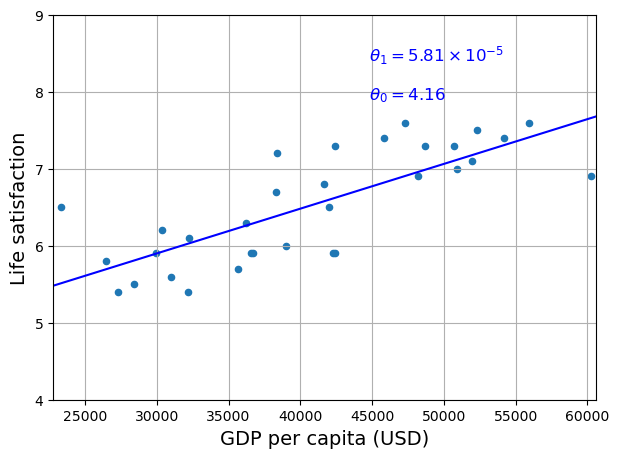

In [33]:
# 산점도 그리기: x축은 1인당 GDP, y축은 삶의 만족도
lifesat.plot(kind='scatter', figsize=(7, 5), grid=True, x=gdppc_col, y=lifesat_col)

# 모델이 학습한 절편과 기울기
theta_0, theta_1 = oecd_linear_model.intercept_[0], oecd_linear_model.coef_[0, 0]

# 선형 회귀 모델의 예측선(직선) 그리기
X_range = np.linspace(min_gdp, max_gdp, 1000) # x축 범위에 대한 1000개의 점 생성
y_range = theta_0 + theta_1 * X_range         # 각 x값에 대한 예측된 y값 계산
plt.plot(X_range, y_range, "b")

# 그래프 내에 절편과 기울기 표기
plt.text(min_gdp + 22_000, max_life_sat - 1.1, fr"$\theta_0 = {theta_0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6, fr"$\theta_1 = {theta_1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

# 축 범위 설정
plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

# 그래프 출력
plt.show()

**훈련된 모델 활용**

`oecd_linear_model`은 한 국가의 1인당 GDP가 주어졌을 때
해당 국가 국민의 삶의 만족도를 예측하도록 훈련되었다.
훈련된 모델의 예측값 계산은 모델의 `predict()` 메서드가 담당한다.

모델을 활용한 예측은 훈련할 때 사용된 훈련셋 데이터에 한정되지 않는다.
예를 들어, 아래 코드는 앞서 훈련셋에서 제외된 8개 국가들의
1인당 GDP를 인자로 지정하여 `predict()` 메서드를 호출하여
8개 국가의 삶의 만족도를 예측한다.

In [39]:
excluded_countries

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Norway,63585.903514,7.6
Switzerland,68393.306004,7.5
Ireland,89688.956958,7.0
Luxembourg,110261.157353,6.9


In [43]:
X_new = excluded_countries[["GDP per capita (USD)"]]
predicted_life_satisfaction = oecd_linear_model.predict(X_new)
predicted_life_satisfaction

array([[ 4.82258638],
       [ 4.93741833],
       [ 4.97360604],
       [ 5.19589635],
       [ 7.85250525],
       [ 8.131978  ],
       [ 9.36997587],
       [10.56591679]])

정보를 보다 명확하게 전달하기 위해 데이터프레임으로 변환한다.

In [47]:
pd.DataFrame(predicted_life_satisfaction, 
             index=excluded_countries.index,
             columns=["Predicted Life Satisfaction"])

,Predicted Life Satisfaction
Country,
South Africa,4.822586
Colombia,4.937418
Brazil,4.973606
Mexico,5.195896
Norway,7.852505
Switzerland,8.131978
Ireland,9.369976
Luxembourg,10.565917


모델 훈련으로 정해진 절편과 기울기를 사용하는 1차 함수 $f(x) = \theta_0 + \theta_1 \cdot x$를 이용하여
$f(x)$를 계산해도 동일한 결과가 나온다.

In [49]:
def linear_model_predict(gdp_per_capita):
    return oecd_linear_model.intercept_[0] + oecd_linear_model.coef_[0, 0] * gdp_per_capita

In [50]:
linear_model_predict(X_new)

,GDP per capita (USD)
Country,
South Africa,4.822586
Colombia,4.937418
Brazil,4.973606
Mexico,5.195896
Norway,7.852505
Switzerland,8.131978
Ireland,9.369976
Luxembourg,10.565917


**`predict()` 메서드의 인자와 반환값**

훈련된 모델의 `predict()` 메서드의 인자는 일반적으로 데이터프레임 또는 2차원 어레이로 지정한다.
그러면 예측값은 2차원 어레이로 반환된다. 

먼저, 데이터프레임 또는 2차원 어레이 입력값의 각 행은
모델이 예측값을 계산할 때 필요한 모든 데이터를 담아야 한다.
`oecd_linear_model`이 한 국가의 삶의 만족도를 예측하기 위해 필요한 정보는 해당 국가의
1인당 GDP 데이터 하나 뿐이다.
따라서 각 국가의 삶의 만족도 예측에 필요한 값은 `[33442.8]` 모양의 1차원 어레이이며,
여러 국가에 대한 1차원 어레이로 구성된 2차원 어레이가 인자로 사용된다.

반환값이 2차원 어레이인 이유는 인자에 대한 이유와 유사한데,
머신러닝 모델이 하나의 입력값에 대해 여러 종류의 예측값을 동시에 예측할 수 있도록 훈련될 수 있기 때문이다.
여기서는 삶의 만족도 한 종류의 값만 예측하도록 훈련되었기에 각 국가별 예측값이 `[삶의 만족도]` 모양의 1차원 어레이다.

만약에 국가별 삶의 만족도 이외에, 예를 들어, 삶의 불만족도 또한 예측하도록 모델을 훈련시켰다면
국가별 예측값은 `[삶의 만족도, 삶의 불만족도]` 모양의 길이가 2인 1차원 어레이가 되었을 것이다.

### 과대적합

머신러닝 알고리즘을 훈련시키다보면 다양한 어려움에 부딪힌다.
여기서는 선형 회귀 모델이 훈련셋에 민감하게 반응하는 과대적합 현상을 살펴 본다.

앞서 제외시킨 8개 국가의 데이터를 포함해서 선형 회귀 모델을 훈련시켜 보자.
제외된 8개 국가는 1인당 GDP가 하위 10% 또는 상위 10% 구간에 포함되는 국가들이며 다음과 같다.

In [51]:
excluded_countries

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Norway,63585.903514,7.6
Switzerland,68393.306004,7.5
Ireland,89688.956958,7.0
Luxembourg,110261.157353,6.9


**새로운 선형 회귀 모델 훈련**

제외되었던 8개 국가를 훈련셋에 포함시키면 훈련은 처음부터 다시 시작해야 한다.
무엇보다도 입력 데이텃과 타깃셋을 새롭게 지정해야 한다.

- 훈련셋

In [53]:
Xfull = lifesat_full[[gdppc_col]]

- 타깃셋

In [56]:
yfull = lifesat_full[[lifesat_col]]

- 새로운 선형회귀 모델 지정 후 훈련

In [57]:
from sklearn.linear_model import LinearRegression

oecd_linear_model_full = LinearRegression()
oecd_linear_model_full.fit(Xfull, yfull)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


아래 코드는 8개 국가를 제외 했을 때의 선형 회귀 모델(파랑 점선)과
포함시켰을 때의 선형 회귀 모델(검정 실선)의 그래프를 동시에 그린다.
두 모델이 상당히 다름을 확인할 수 있다.

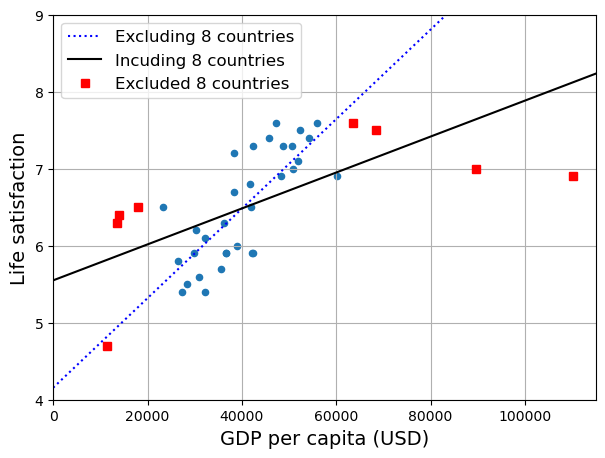

In [72]:
# 40개 국가 산점도
lifesat_full.plot(kind='scatter', figsize=(7, 5), x=gdppc_col, y=lifesat_col, grid=True)

# 32개 국가 대상으로 훈련된 선형 회귀 모델
X_range = np.linspace(0, 115_000, 1000)
plt.plot(X_range, theta_0 + theta_1 * X_range, "b:", label="Excluding 8 countries")

# 40개 국가 대상으로 훈련된 선형 회귀 모델
theta_0_full, theta_1_full = oecd_linear_model_full.intercept_[0], oecd_linear_model_full.coef_[0][0]
plt.plot(X_range, theta_0_full + theta_1_full * X_range, "k", label="Incuding 8 countries")

# 제외된 8개 국가의 실제 데이터 포인트를 빨간색 사각형으로 표시
for i, country in enumerate(excluded_countries.index):
    pos_data_x, pos_data_y = excluded_countries.loc[country]
    # 범례에 한 번만 표시되도록 label을 첫 번째 요소에만 추가합니다.
    label = "Excluded 8 countries" if i == 0 else None
    plt.plot(pos_data_x, pos_data_y, "rs", label=label)

plt.axis([0, 115_000, min_life_sat, max_life_sat])
plt.legend()
plt.show()

결론적으로, 8개 국가를 포함하는 경우와 그렇지 않은 경우에는 상당히 다른 선형 회귀 모델이 훈련된다.
이처럼 모델 훈련 결과가 훈련에 사용된 데이터셋에 민감하게 반응하는 현상을 **과대적합**<font size='2'>overfitting</font>이라 한다.

## 연습문제

**문제 1**

머신러닝 모델의 훈련은 내부에서 모든 데이터를 어레이로 처리한다.
삶의 만족도를 예측하는 선형회귀 모델의 훈련에 필요한 훈련셋과 타깃셋 모두 넘파이 어레이로 지정한 다음에
모델의 훈련을 진행하라.